In [1]:
import pandas as pd
import numpy as np

In [5]:
diabetes_data = pd.read_csv("Diabetes.csv")

In [6]:
diabetes_data.head

<bound method NDFrame.head of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                       0.351   31        0  
2                       0.672   32        1  
3                       0.167   21        0  
4                       2.288   33        1  
..                        ...  ...      ...  
763                     0.171   63        0  
764                     0.340   27        0  
765                     0.245   30        0  
766                     0.349   47        1  
767                     0.315   23        0  

[768 rows x 9 columns]>

In [7]:
# Load useful libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

# Separate Features and Target Variables
X = diabetes_data.drop(columns='Outcome')
y = diabetes_data['Outcome']

# Create Train & Test Data
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,
                                                	stratify =y,
                                                	random_state = 13)

# Build the model
rf_clf = RandomForestClassifier(max_features=2, n_estimators =100 ,bootstrap = True)

rf_clf.fit(X_train, y_train)

# Make prediction on the testing data
y_pred = rf_clf.predict(X_test)

# Classification Report
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83       165
           1       0.57      0.70      0.63        66

    accuracy                           0.76       231
   macro avg       0.72      0.74      0.73       231
weighted avg       0.78      0.76      0.77       231



In [8]:

pip install shap


In [9]:
import shap
import matplotlib.pyplot as plt

# load JS visualization code to notebook
shap.initjs()

# Create the explainer
explainer = shap.TreeExplainer(rf_clf)

shap_values = explainer(X_test)

# Assuming shap_values is your array with shape (231, 8, 2)

# Extract the first component (231, 8)
shap_values_1 = shap_values[:, :, 0]

# Extract the second component (231, 8)
shap_values_2 = shap_values[:, :, 1]

print(shap_values.values [:,:,0])

print(shap_values.shape)

[[ 3.53142011e-02 -3.24455077e-01 -1.50237031e-02 ...  1.19841315e-01
  -2.46208369e-02  8.39389076e-02]
 [ 4.92515077e-02  2.10112318e-02 -3.82464701e-03 ... -9.48348596e-03
   1.37303423e-02  1.59194119e-01]
 [-9.28711092e-05 -2.83344332e-01  1.54453145e-02 ... -3.70802964e-02
  -5.03665735e-02 -8.71928533e-02]
 ...
 [ 1.47090742e-02 -3.94908580e-02  3.13910866e-02 ... -5.26555045e-02
  -5.52551474e-02 -7.36045155e-02]
 [ 3.03639542e-02  1.17457539e-01 -1.13508667e-02 ... -3.68942697e-02
   7.20071999e-02  3.94139505e-02]
 [ 3.21161692e-02  9.49908926e-02  8.88126256e-03 ...  9.38990872e-02
   1.18396968e-02  5.11766769e-02]]
(231, 8, 2)


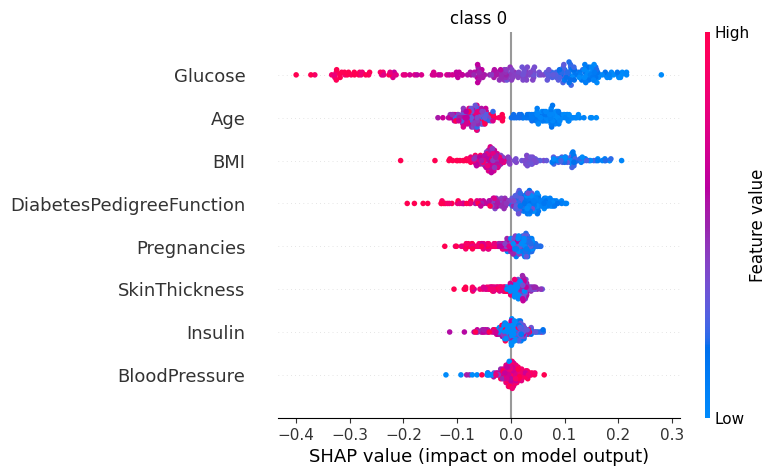

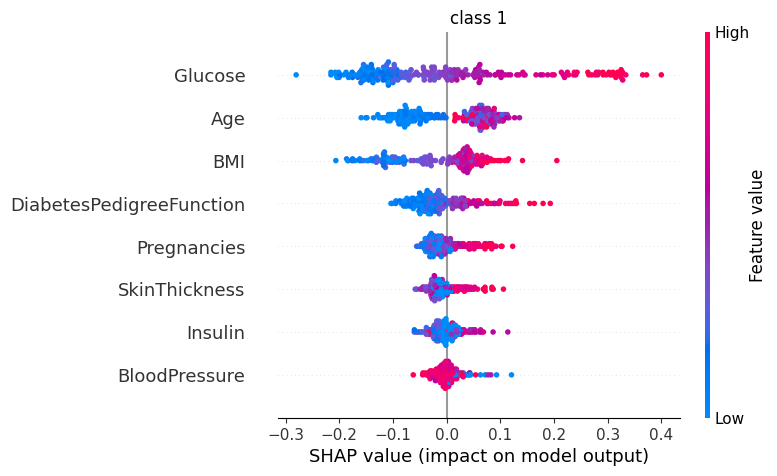

In [10]:
# Plot SHAP summary for each output variable
#for i in range(shap_values.shape[2]):
 #   shap.summary_plot(shap_values[:, :, i], features=X_test, show=False)
  #  plt.title(f'SHAP Summary Plot for Activity {i+1}')
   # plt.show()
import matplotlib.pyplot as plt

# Assuming you have defined shap_values_1 and X_test

# Plot the SHAP summary plot for the first class
shap.summary_plot(shap_values[:,:,0], features=X_test, show=False)
plt.title ("class 0")
# Display the plot
plt.show()
# Plot the SHAP summary plot for the second class
shap.summary_plot(shap_values[:,:,1], features=X_test, show=False)
plt.title ("class 1")
# Display the plot
plt.show()

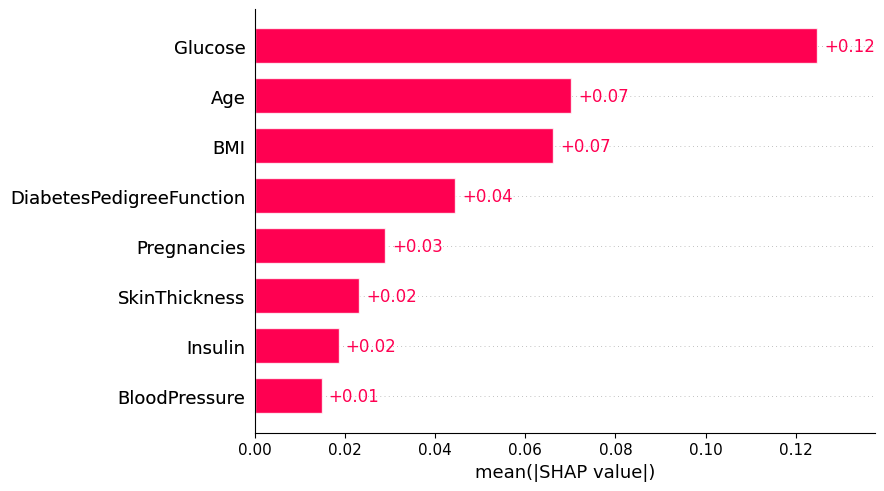

In [11]:
# Plot SHAP bar plot for the second output variable
shap.plots.bar(shap_values[:,:,1])
plt.show()

In [12]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b6c1bc23966babb36327006b2a29294094575afb0ad17eccb551a0b3064bf596
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [13]:
# Import the LimeTabularExplainer module
from lime.lime_tabular import LimeTabularExplainer

# Get the class names
class_names = ['Has diabetes', 'No diabetes']

# Get the feature names
feature_names = list(X_train.columns)

# Fit the Explainer on the training data set using the LimeTabularExplainer
explainer = LimeTabularExplainer(X_train.values, feature_names =
                                 feature_names,
                                 class_names = class_names,
                                 mode = 'classification')

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt_clf = DecisionTreeClassifier(max_depth = 3, min_samples_leaf = 2)
dt_clf.fit(X_train, y_train)

# Predict on the test data and evaluate the model
y_pred = dt_clf.predict(X_test)

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.89      0.73      0.80       181
           1       0.41      0.66      0.50        50

    accuracy                           0.72       231
   macro avg       0.65      0.70      0.65       231
weighted avg       0.78      0.72      0.74       231



In [15]:
#Perform the explanation on the 8th instance in the test data
explaination = explainer.explain_instance(X_test.iloc[8],rf_clf.predict_proba)

#show the result of the model's explaination
explaination.show_in_notebook(show_table = True, show_all = False)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt_clf = DecisionTreeClassifier(max_depth = 3, min_samples_leaf = 2)
dt_clf.fit(X_train, y_train)

# Predict on the test data and evaluate the model
y_pred = dt_clf.predict(X_test)

print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.89      0.73      0.80       181
           1       0.41      0.66      0.50        50

    accuracy                           0.72       231
   macro avg       0.65      0.70      0.65       231
weighted avg       0.78      0.72      0.74       231



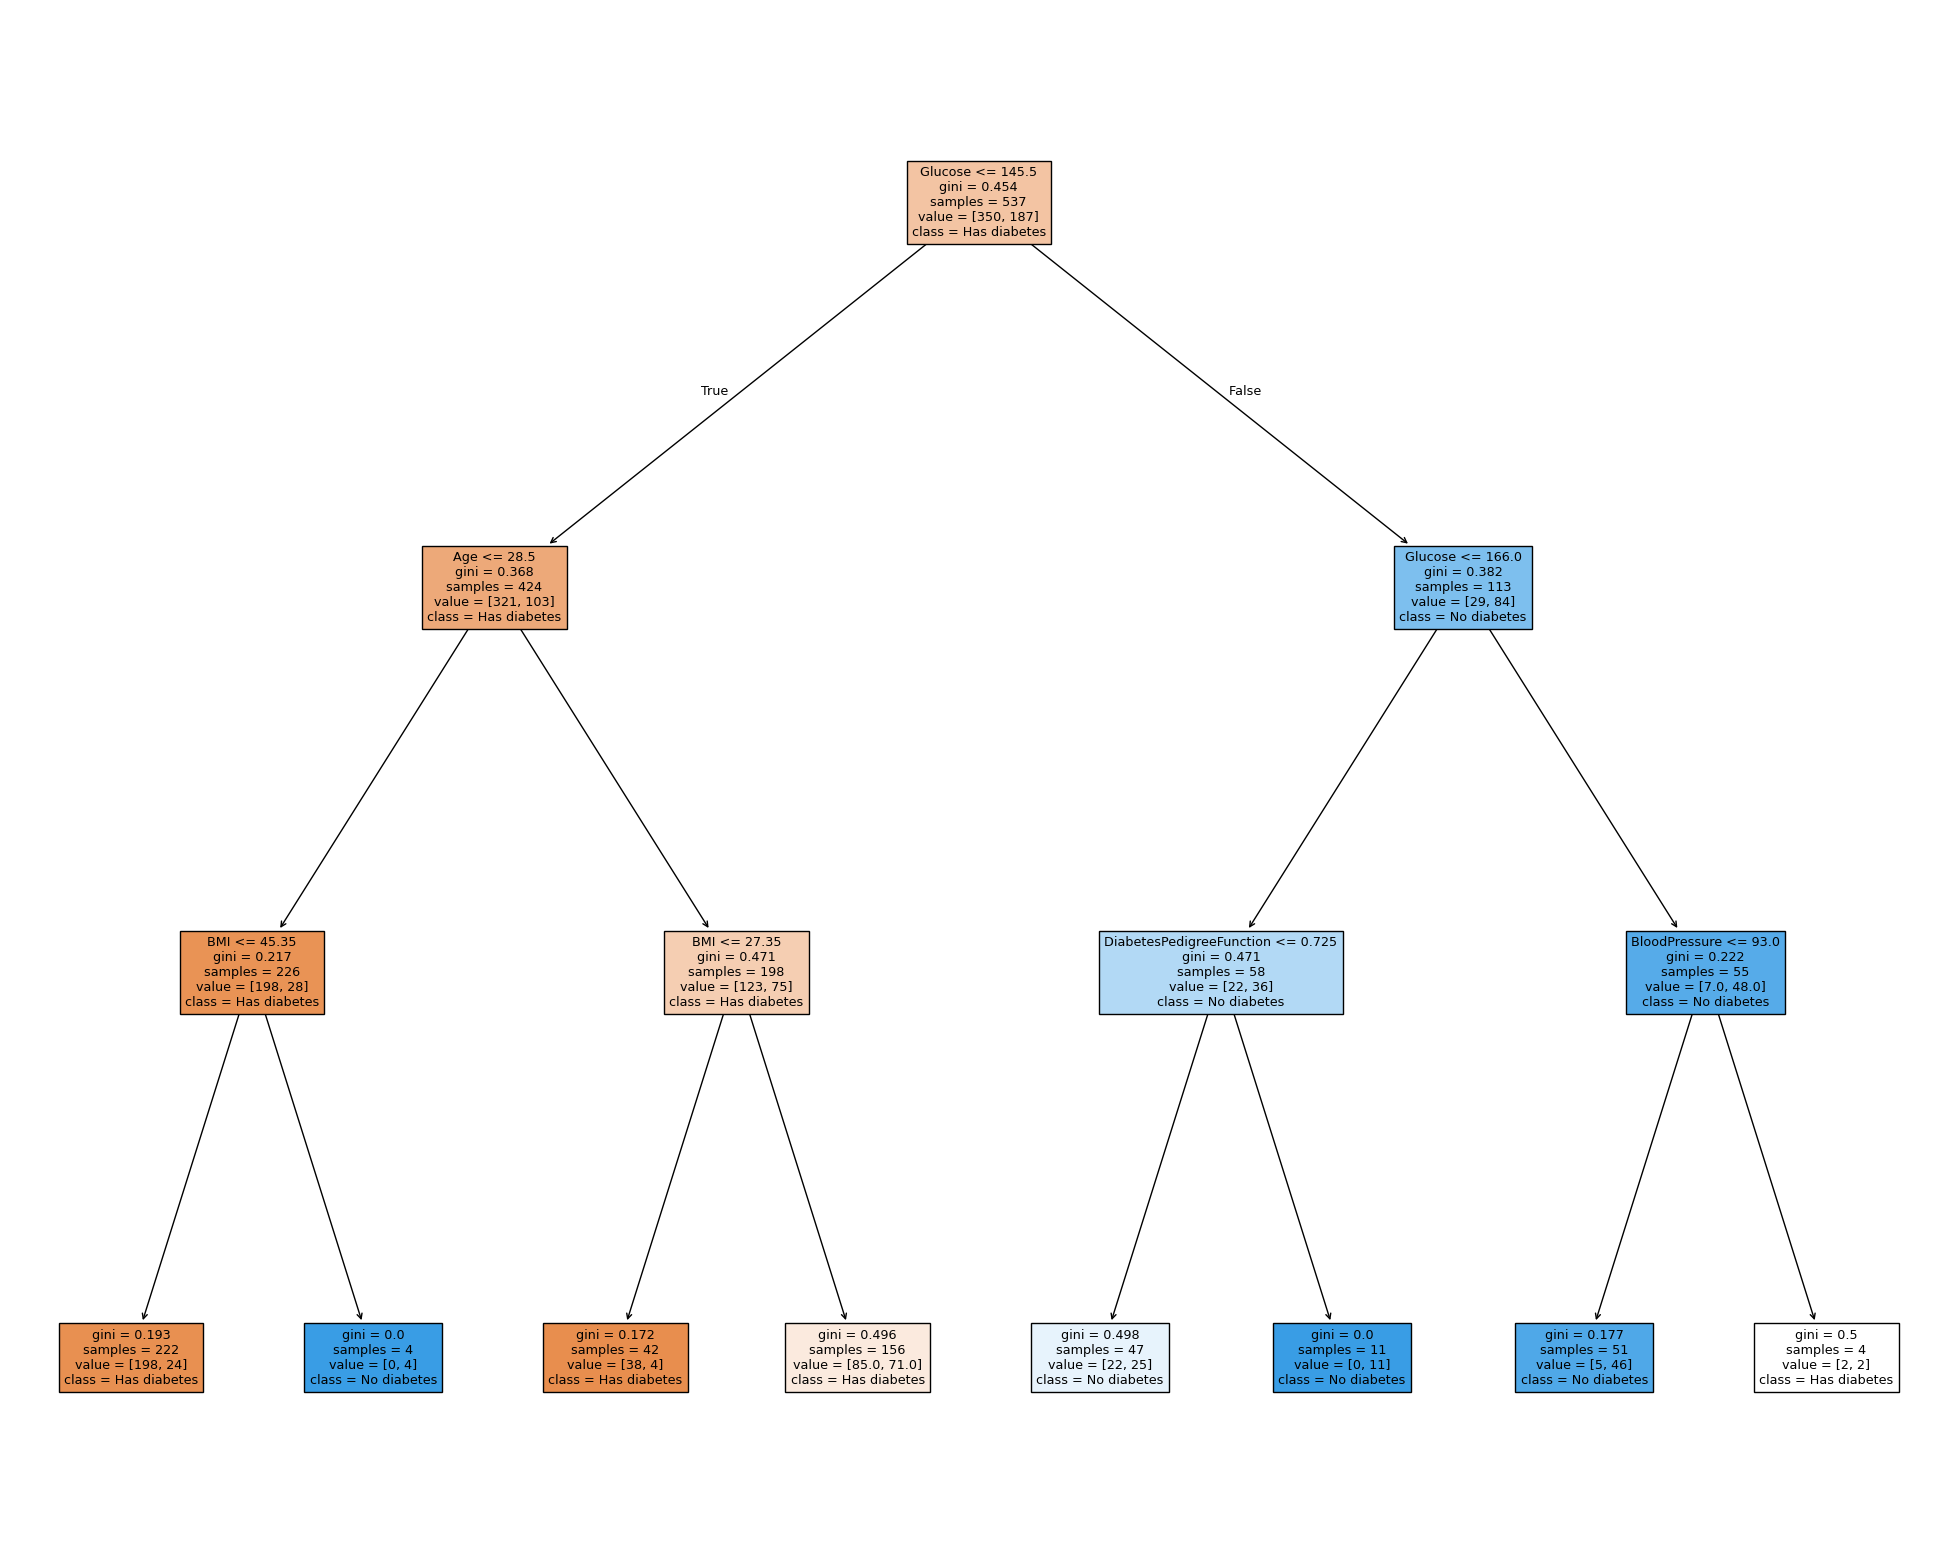

In [17]:
fig = plt.figure(figsize=(25,20))
_ = plot_tree(dt_clf,
               	feature_names = feature_names,
               	class_names = class_names,
               	filled=True)